### **Basic libraries**

In [ ]:
import pandas as pd
import numpy as np
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Pandas version: 2.2.2
Numpy version: 2.0.2


### **Load the raw rainfall data**

In [ ]:
df_raw_rain = pd.read_csv("raw_rainfall.csv")

# Basic information
print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
print(df_raw_rain.head())
print(f"Shape of the dataset: {df_raw_rain.shape}")
print(f"Columns: {df_raw_rain.columns.tolist()}")
print("\nData types:")
print(df_raw_rain.dtypes)

Dataset loaded successfully!

First 5 rows:
  Station  Year  Month    1     2    3    4    5    6    7  ...   22   23  \
0   Bogra  1948      1  0.0   0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
1   Bogra  1948      2  0.0   0.0  0.0  4.0  1.0  0.0  0.0  ...  0.0  0.0   
2   Bogra  1948      3  0.0   0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
3   Bogra  1948      4  0.0   0.0  0.0  0.0  7.0  0.0  0.0  ...  0.0  0.0   
4   Bogra  1948      5  0.0  24.0  0.0  0.0  0.0  0.0  0.0  ...  9.0  7.0   

     24    25    26   27   28   29    30   31  
0   0.0   0.0   0.0  0.0  0.0  0.0   0.0  0.0  
1   0.0   0.0   0.0  0.0  0.0  0.0   0.0  0.0  
2   0.0   0.0   0.0  0.0  0.0  0.0   0.0  0.0  
3   0.0   0.0   0.0  0.0  0.0  0.0  18.0  0.0  
4  24.0  31.0  14.0  0.0  1.0  8.0   0.0  0.0  

[5 rows x 34 columns]
Shape of the dataset: (20778, 34)
Columns: ['Station', 'Year', 'Month', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20',

### **Basic Understanding of the raw rainfall data**

In [ ]:
# Check for missing values
print("Missing values per column:")
print(df_raw_rain.isnull().sum().sum(), "total missing values")

Missing values per column:
0 total missing values


In [ ]:
# Check unique stations
print("\nNumber of stations:", df_raw_rain['Station'].nunique())
print("Stations:", df_raw_rain['Station'].unique()[:])


Number of stations: 35
Stations: ['Bogra' 'Comilla' "Cox's Bazar" 'Dinajpur' 'Faridpur' 'Jessore' 'Khulna'
 'Mymensingh' 'Satkhira' 'Srimangal' 'Barisal' 'Chittagong' 'M.court'
 'Dhaka' 'Rangpur' 'Sylhet' 'Rangamati' 'Ishurdi' 'Chandpur' 'Rajshahi'
 'Bhola' 'Hatiya' 'Sandwip' 'Feni' 'Patuakhali' 'Khepupara' 'Kutubdia'
 'Madaripur' 'Sitakunda' 'Teknaf' 'Tangail' 'chuadanga' 'Mongla' 'sydpur'
 'Ambagan(Ctg)']


In [ ]:
# Check year range
print("\nYear range:", df_raw_rain['Year'].min(), "to", df_raw_rain['Year'].max())

# Check month range
print("Month range:", df_raw_rain['Month'].min(), "to", df_raw_rain['Month'].max())


Year range: 1948 to 2014
Month range: 1 to 12


### **Reshape the data from wide format to long format**

In [ ]:
# Melt the daily columns into one 'Day' and 'Rainfall' column
daily_cols = [str(i) for i in range(1, 32)]   # columns '1' to '31'

df_long_rain = pd.melt(
    df_raw_rain,
    id_vars=['Station', 'Year', 'Month'],
    value_vars=daily_cols,
    var_name='Day',
    value_name='Rainfall'
)

print("\nFirst 5 rows of long format:")
print(df_long_rain.head())


First 5 rows of long format:
  Station  Year  Month Day  Rainfall
0   Bogra  1948      1   1       0.0
1   Bogra  1948      2   1       0.0
2   Bogra  1948      3   1       0.0
3   Bogra  1948      4   1       0.0
4   Bogra  1948      5   1       0.0


In [ ]:
# Convert Day to integer
df_long_rain['Day'] = df_long_rain['Day'].astype(int)

# Create proper datetime column
df_long_rain['Date'] = pd.to_datetime(
    df_long_rain[['Year', 'Month', 'Day']],
    errors='coerce'
)

# Drop any invalid dates (e.g., 31st Feb)
df_long_rain = df_long_rain.dropna(subset=['Date'])

# Sort by date and station
df_long_rain = df_long_rain.sort_values(['Station', 'Date']).reset_index(drop=True)

print("Data reshaped to long format!")
print(f"New shape: {df_long_rain.shape}")
print("\nFirst 5 rows of long format:")
print(df_long_rain.head())
print("\nInfo:")
print(df_long_rain.info())

Data reshaped to long format!
New shape: (632377, 6)

First 5 rows of long format:
        Station  Year  Month  Day  Rainfall       Date
0  Ambagan(Ctg)  1999      1    1       0.0 1999-01-01
1  Ambagan(Ctg)  1999      1    2       0.0 1999-01-02
2  Ambagan(Ctg)  1999      1    3       0.0 1999-01-03
3  Ambagan(Ctg)  1999      1    4       0.0 1999-01-04
4  Ambagan(Ctg)  1999      1    5       0.0 1999-01-05

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 632377 entries, 0 to 632376
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Station   632377 non-null  object        
 1   Year      632377 non-null  int64         
 2   Month     632377 non-null  int64         
 3   Day       632377 non-null  int64         
 4   Rainfall  632377 non-null  float64       
 5   Date      632377 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 28.9+ MB
None


In [ ]:
# Save the cleaned long-format data
df_long_rain.to_csv('rainfall.csv', index=False)
print("\nCleaned long-format file saved as rainfall.csv")


Cleaned long-format file saved as rainfall.csv


### **Quick exploratory analysis - Daily, Monthly and Annual rainfall summary**

In [ ]:
# Station-wise average rainfall (to see which areas get more rain)

# Average daily rainfall per station
station_avg = df_long_rain.groupby('Station')['Rainfall'].mean().sort_values(ascending=False)

print("All stations with average daily rainfall:")
print(station_avg)

All stations with average daily rainfall:
Station
Teknaf          11.002921
Sylhet          10.775534
Cox's Bazar      9.760952
Sandwip          9.499912
Sitakunda        8.311501
Hatiya           8.216030
M.court          8.063577
Ambagan(Ctg)     7.947703
Kutubdia         7.905215
Chittagong       7.808334
Feni             7.647202
Khepupara        7.326482
Patuakhali       6.813934
Rangamati        6.651833
Srimangal        6.110479
Bhola            6.088805
Comilla          6.054928
sydpur           5.820089
Mymensingh       5.724533
Rangpur          5.724315
Barisal          5.702643
Dhaka            5.522493
Chandpur         5.473130
Madaripur        5.351913
Mongla           5.226987
Dinajpur         5.038472
Faridpur         5.030879
Tangail          4.942049
Khulna           4.582011
Bogra            4.579422
Satkhira         4.394957
Jessore          4.303766
chuadanga        4.019330
Rajshahi         4.014339
Ishurdi          3.948257
Name: Rainfall, dtype: float64


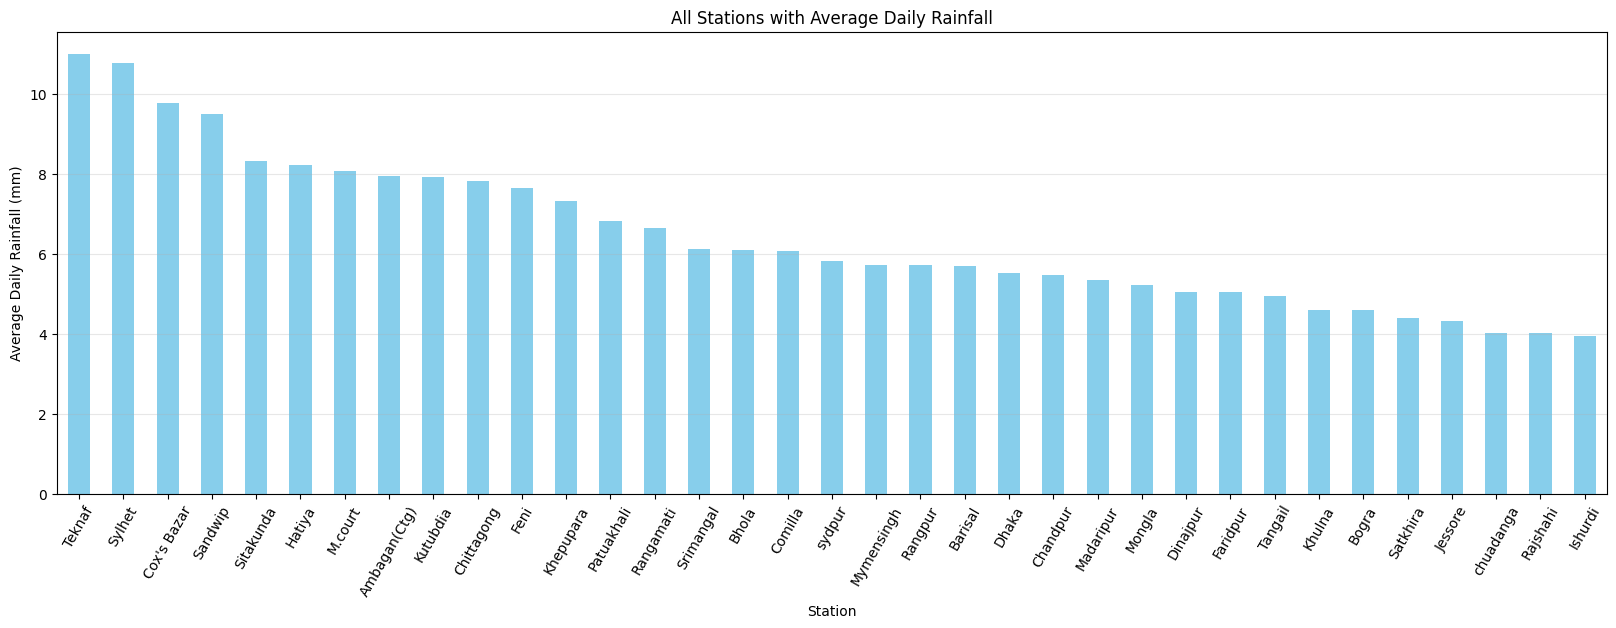

In [ ]:
# Simple bar plot for all stations
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
station_avg.plot(kind='bar', color='skyblue')
plt.title('All Stations with Average Daily Rainfall')
plt.xlabel('Station')
plt.ylabel('Average Daily Rainfall (mm)')
plt.xticks(rotation=60)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
monthly_total_per_station = df_long_rain.groupby(['Station', 'Year', 'Month'])['Rainfall'].sum().reset_index()

print("Monthly total rainfall per station (first 5 rows):")
print(monthly_total_per_station.head())

Monthly total rainfall per station (first 5 rows):
        Station  Year  Month  Rainfall
0  Ambagan(Ctg)  1999      1       0.0
1  Ambagan(Ctg)  1999      2       0.0
2  Ambagan(Ctg)  1999      3       1.0
3  Ambagan(Ctg)  1999      4       0.0
4  Ambagan(Ctg)  1999      5     403.0


### **Rainfall Trends for Teknaf**

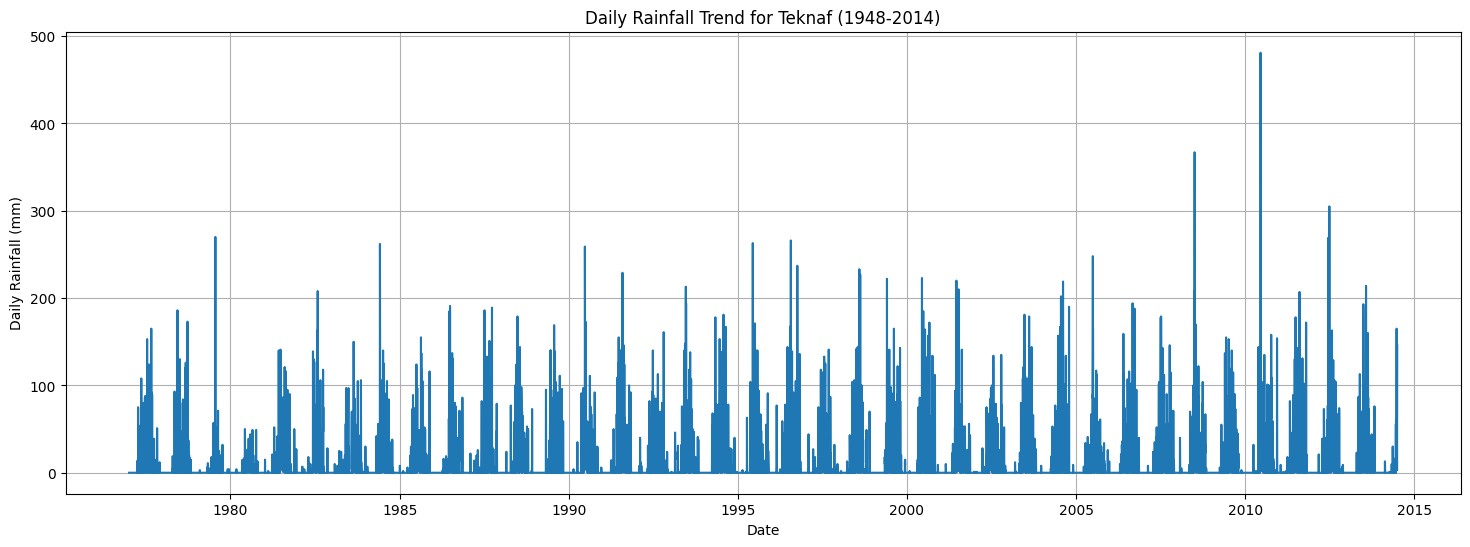

Daily rainfall trend for Teknaf created.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for 'Teknaf' station
teknaf_daily_rain = df_long_rain[df_long_rain['Station'] == 'Teknaf'].copy()

plt.figure(figsize=(18, 6))
sns.lineplot(x='Date', y='Rainfall', data=teknaf_daily_rain)
plt.title('Daily Rainfall Trend for Teknaf (1948-2014)')
plt.xlabel('Date')
plt.ylabel('Daily Rainfall (mm)')
plt.grid(True)
plt.show()

print("Daily rainfall trend for Teknaf created.")

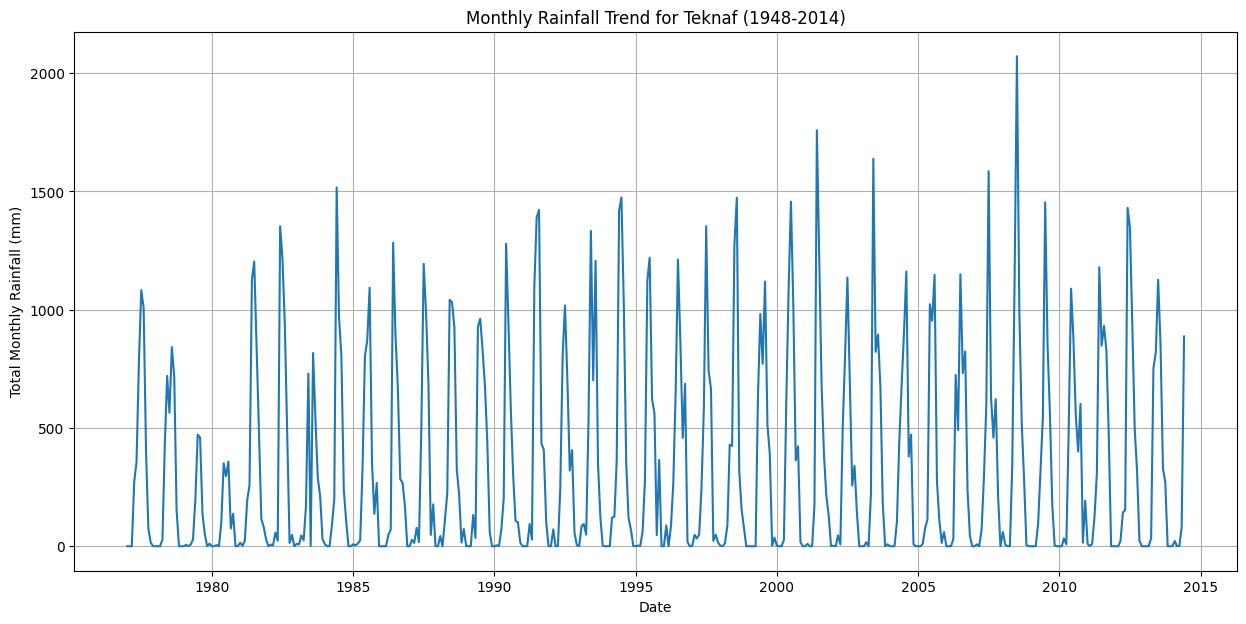

Monthly rainfall trend for Teknaf created.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for 'Teknaf' station
teknaf_monthly_rain = df_long_rain[df_long_rain['Station'] == 'Teknaf'].groupby(['Year', 'Month'])['Rainfall'].sum().reset_index()

# Create a 'Date' column for plotting
teknaf_monthly_rain['Date'] = pd.to_datetime(teknaf_monthly_rain['Year'].astype(str) + '-' + teknaf_monthly_rain['Month'].astype(str) + '-01')

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Rainfall', data=teknaf_monthly_rain)
plt.title('Monthly Rainfall Trend for Teknaf (1948-2014)')
plt.xlabel('Date')
plt.ylabel('Total Monthly Rainfall (mm)')
plt.grid(True)
plt.show()

print("Monthly rainfall trend for Teknaf created.")

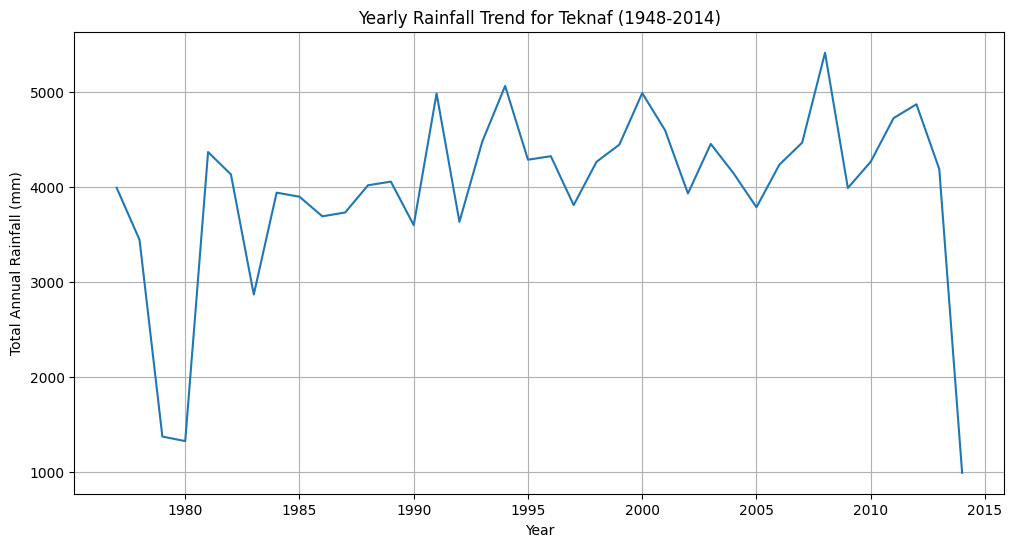

Yearly rainfall trend for Teknaf created.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for 'Teknaf' station and calculate annual total rainfall
teknaf_annual_rain = df_long_rain[df_long_rain['Station'] == 'Teknaf'].groupby('Year')['Rainfall'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Rainfall', data=teknaf_annual_rain)
plt.title('Yearly Rainfall Trend for Teknaf (1948-2014)')
plt.xlabel('Year')
plt.ylabel('Total Annual Rainfall (mm)')
plt.grid(True)
plt.show()

print("Yearly rainfall trend for Teknaf created.")

### **Rainfall Trends for Bangladesh (across all stations)**

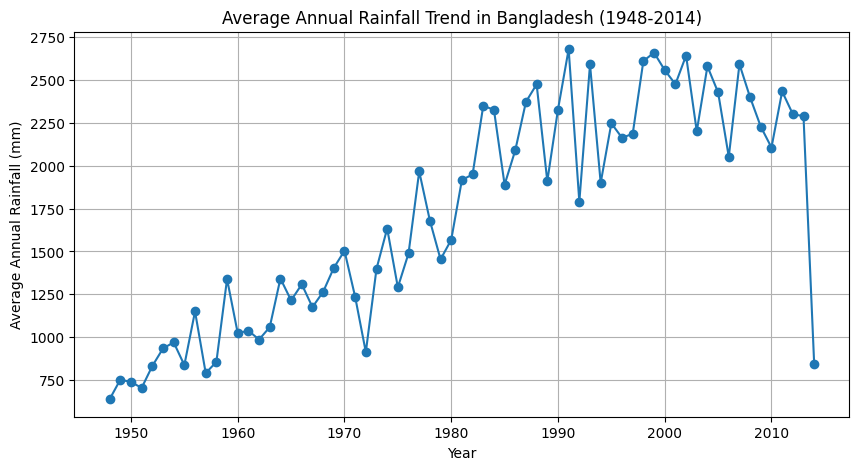

Yearly rainfall trend for all stations created.


In [ ]:
# Calculate annual total rainfall (average across all stations)
annual_rain = df_long_rain.groupby('Year')['Rainfall'].sum() / df_long_rain['Station'].nunique()

# Plot - Average Annual Rainfall Trend
plt.figure(figsize=(10, 5))
annual_rain.plot(kind='line', marker='o')
plt.title('Average Annual Rainfall Trend in Bangladesh (1948-2014)')
plt.xlabel('Year')
plt.ylabel('Average Annual Rainfall (mm)')
plt.grid(True)
plt.show()

print("Yearly rainfall trend for all stations created.")

Average Monthly Rainfall (across all stations):
Month
1       377.371429
2       935.771429
3      2163.400000
4      5379.400000
5     12953.371429
6     22786.457143
7     24616.514286
8     19829.942857
9     15188.114286
10     8727.600000
11     1680.771429
12      386.000000
Name: Rainfall, dtype: float64


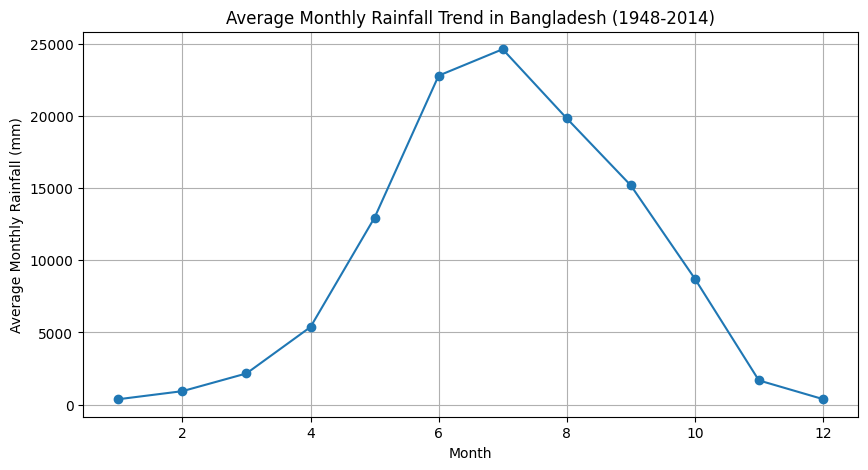

In [ ]:
# Calculate monthly total rainfall (average across all stations)
monthly_avg = df_long_rain.groupby('Month')['Rainfall'].sum() / df_long_rain['Station'].nunique()

print("Average Monthly Rainfall (across all stations):")
print(monthly_avg)

# Plot - Average Monthly Rainfall Trend
plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='line', marker='o')
plt.title('Average Monthly Rainfall Trend in Bangladesh (1948-2014)')
plt.xlabel('Month')
plt.ylabel('Average Monthly Rainfall (mm)')
plt.grid(True)
plt.show()

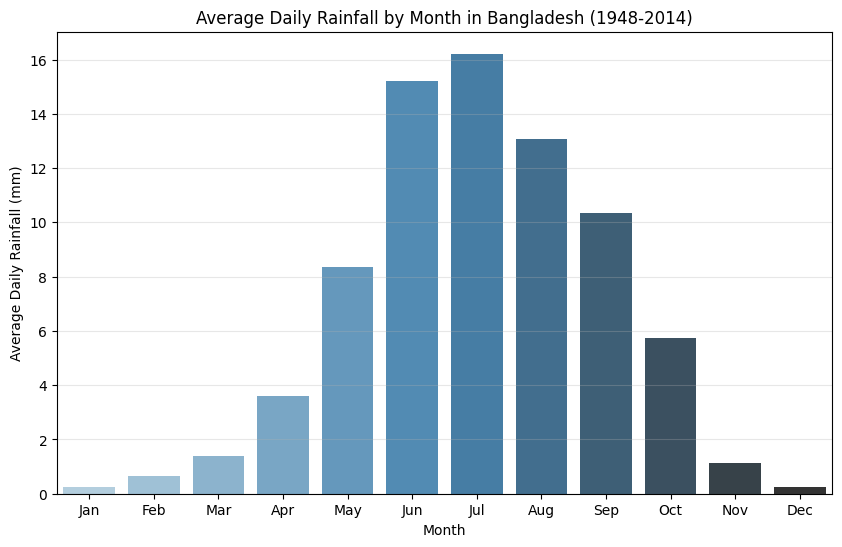

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average monthly rainfall across all stations and years
monthly_avg = df_long_rain.groupby('Month')['Rainfall'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Rainfall', data=monthly_avg, hue='Month', palette='Blues_d', legend=False)
plt.title('Average Daily Rainfall by Month in Bangladesh (1948-2014)')
plt.xlabel('Month')
plt.ylabel('Average Daily Rainfall (mm)')
plt.grid(axis='y', alpha=0.3)

# Add month names for better readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=range(12), labels=month_names)

plt.show()

### **Average Monthly Rainfall by Station (Heatmap)**

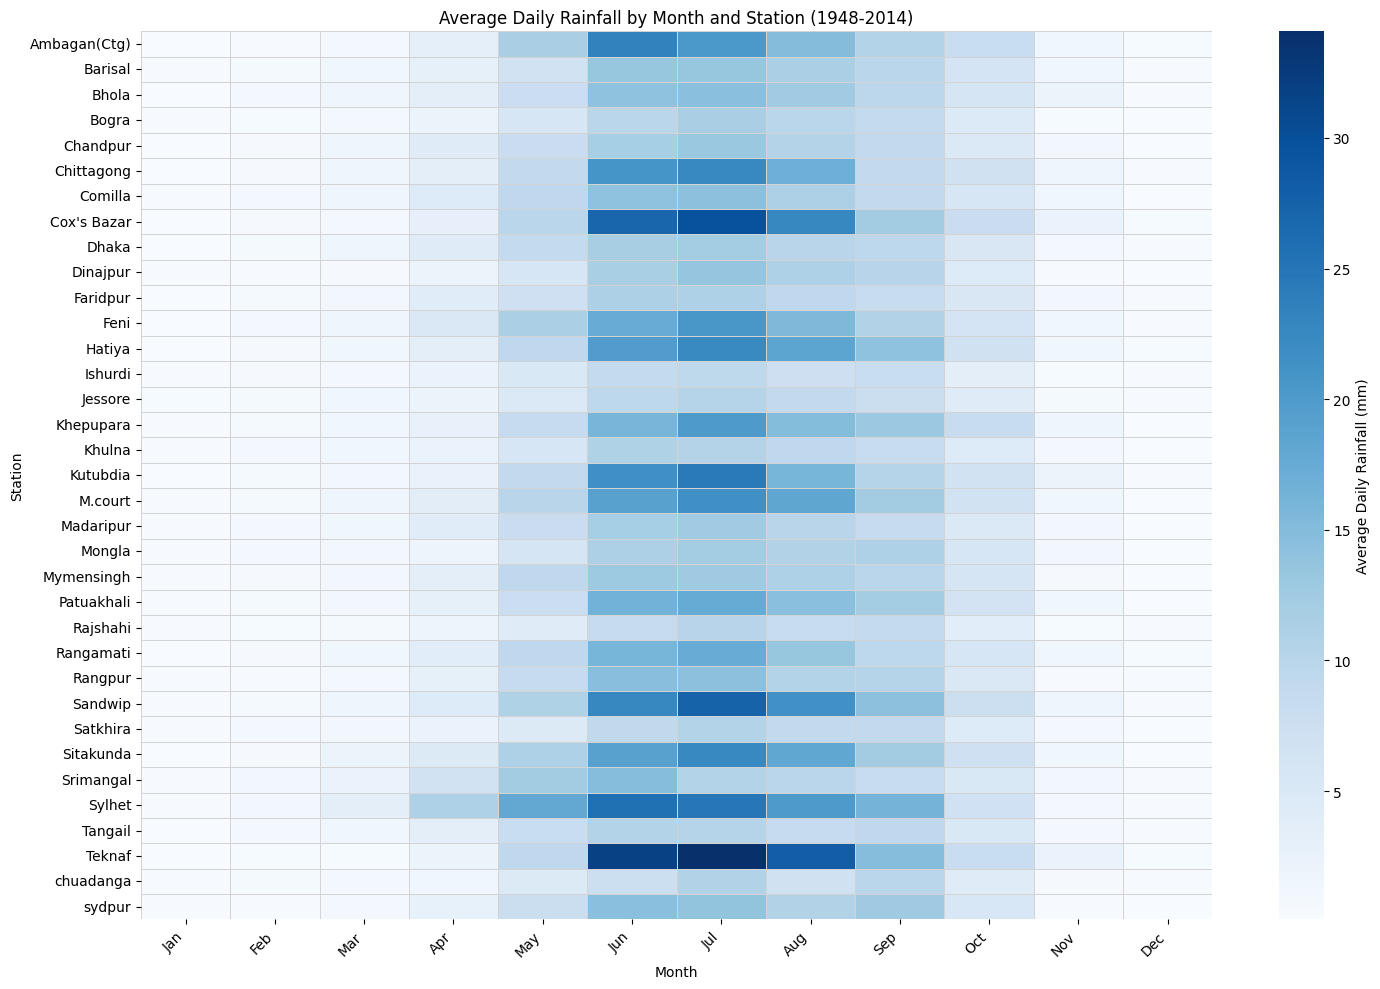

Heatmap of average monthly rainfall per station created.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average monthly rainfall for each station
monthly_avg_per_station = df_long_rain.groupby(['Station', 'Month'])['Rainfall'].mean().reset_index()

# Pivot the table for heatmap
heatmap_data = monthly_avg_per_station.pivot(index='Station', columns='Month', values='Rainfall')

plt.figure(figsize=(15, 10))
sns.heatmap(heatmap_data, cmap='Blues', fmt=".1f", linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'Average Daily Rainfall (mm)'})
plt.title('Average Daily Rainfall by Month and Station (1948-2014)')
plt.xlabel('Month')
plt.ylabel('Station')

# Add month names for better readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=np.arange(1, 13) - 0.5, labels=month_names, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Heatmap of average monthly rainfall per station created.")